In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10,5)

In [4]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [7]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3


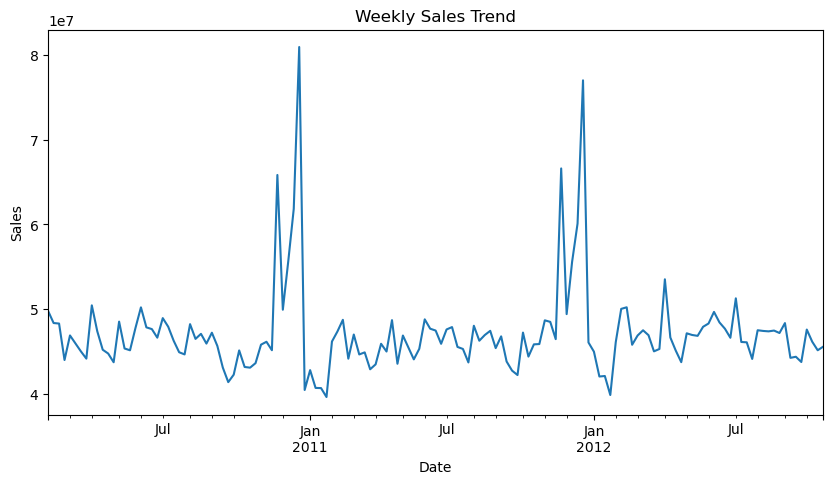

In [10]:
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()
sales_trend.plot()
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

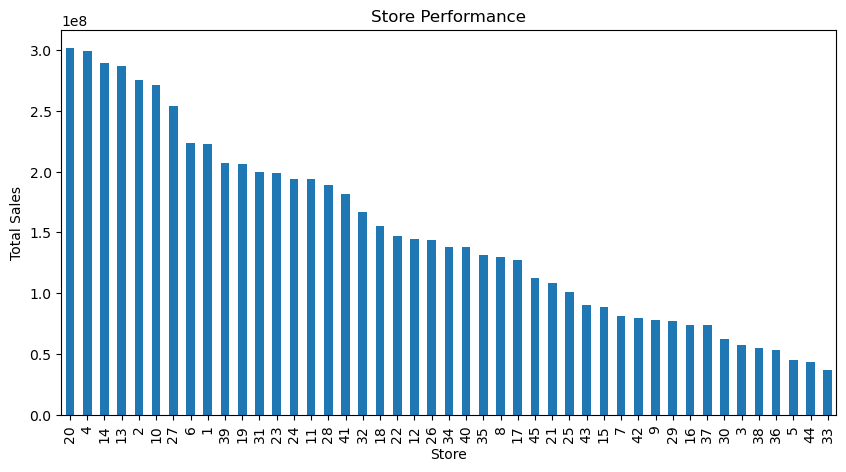

In [11]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()
store_sales.sort_values(ascending=False).plot(kind='bar')
plt.title("Store Performance")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

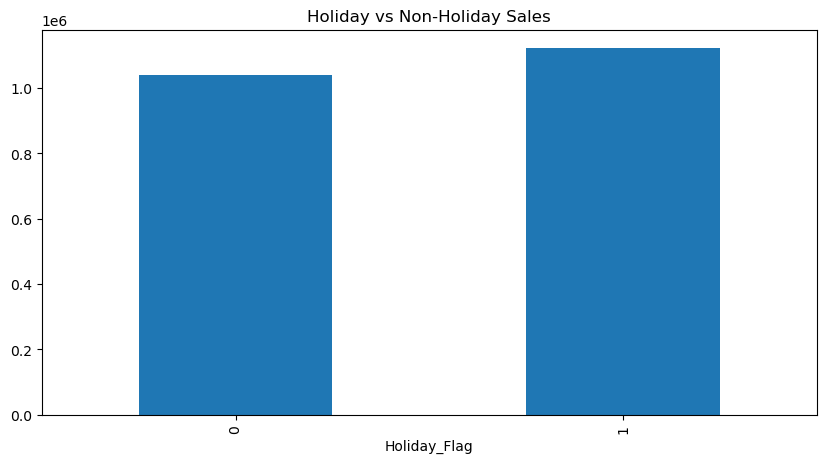

In [12]:
holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
holiday_sales.plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

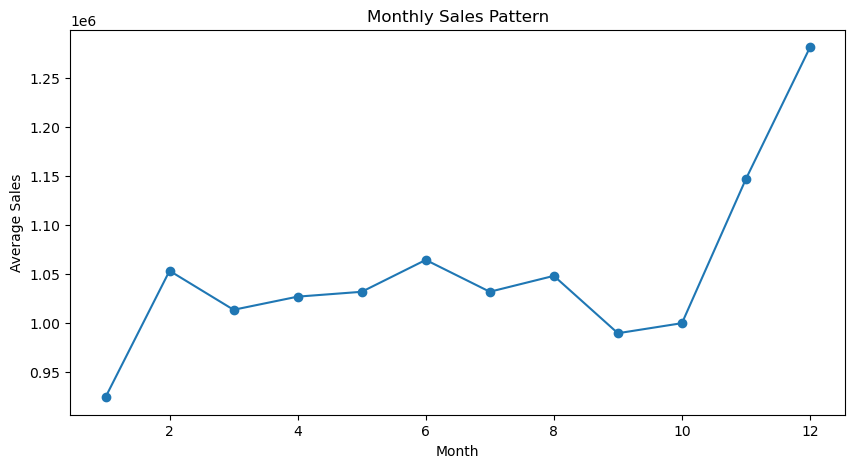

In [13]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

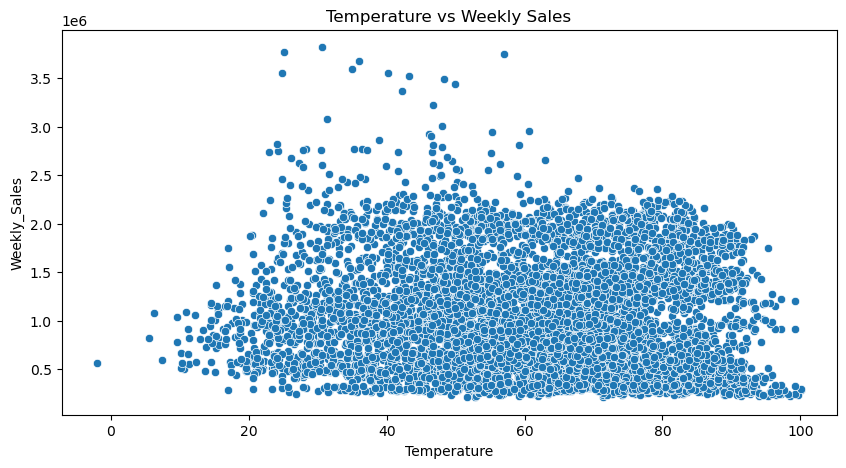

In [15]:
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df) 
plt.title('Temperature vs Weekly Sales') 
plt.show()

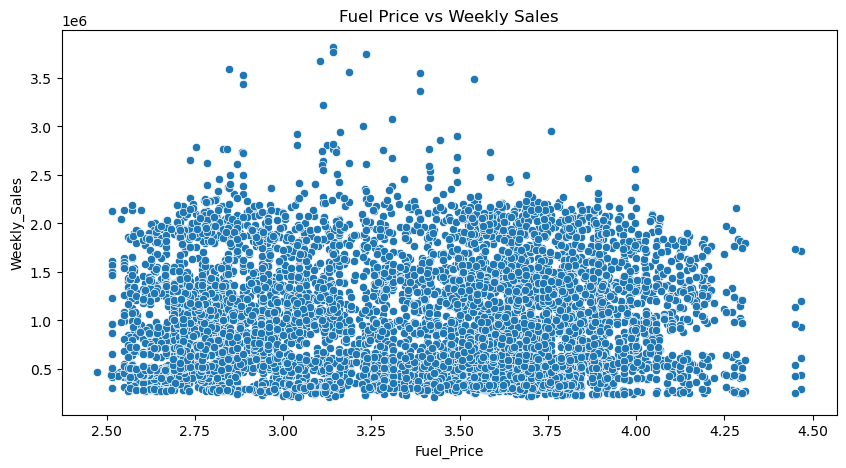

In [16]:
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df) 
plt.title('Fuel Price vs Weekly Sales') 
plt.show()

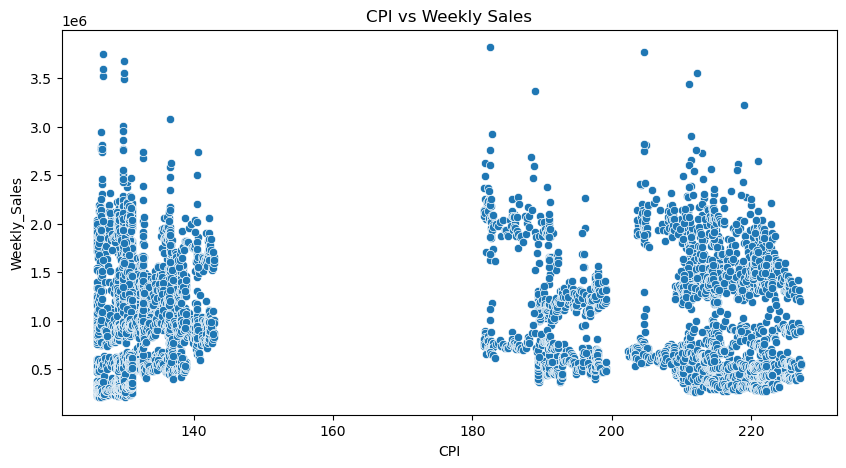

In [17]:
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df) 
plt.title('CPI vs Weekly Sales') 
plt.show()

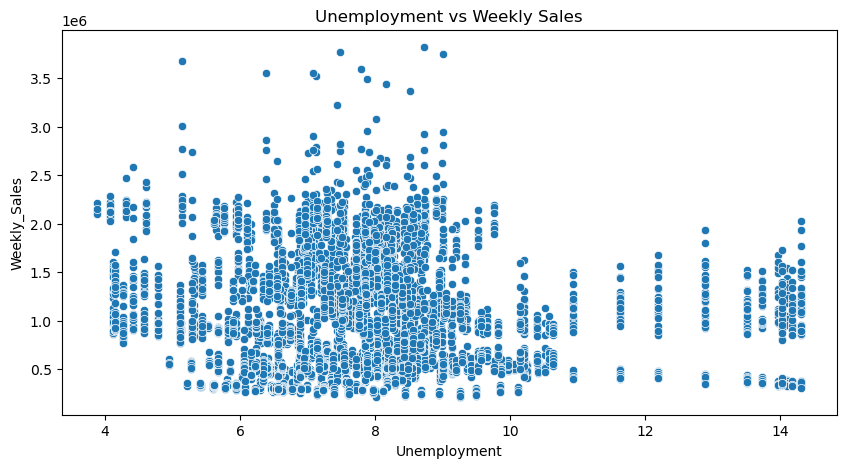

In [18]:
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df) 
plt.title('Unemployment vs Weekly Sales') 
plt.show()

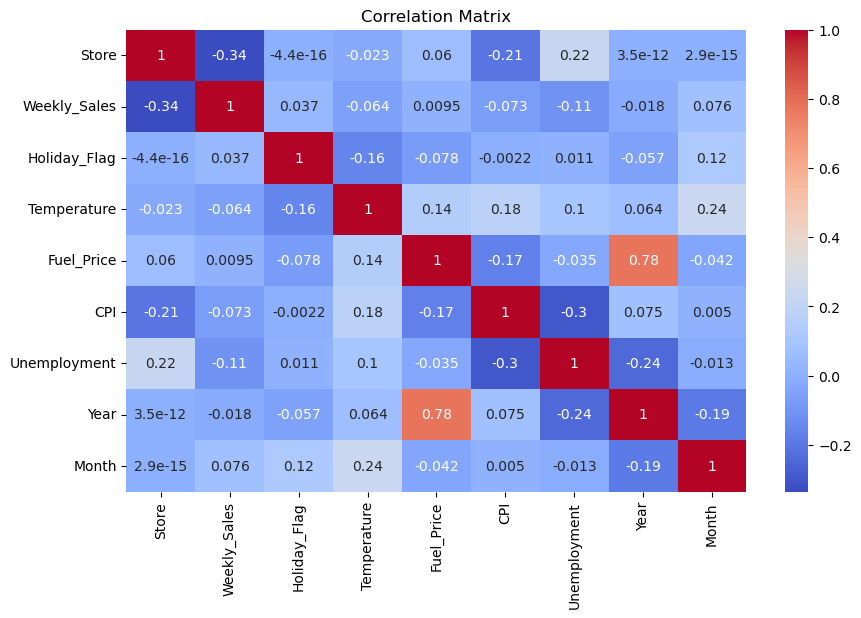

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Matrix")
plt.show()